In [ ]:
# 📦 Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel

# 📥 Load NPI dataset
npi_df = pd.read_csv("/content/All_Subjects_NPI_22Jan2025.csv")

# 🧮 Create Sleep_Severity label
def create_sleep_label(row):
    if row['NPIK'] == 0:
        return 0
    else:
        return row['NPIK9B']

npi_df['Sleep_Severity'] = npi_df.apply(create_sleep_label, axis=1)
npi_df = npi_df.dropna(subset=['Sleep_Severity'])
labels = npi_df['Sleep_Severity'].astype(int)

# 🧹 Drop leakage columns
drop_cols = [col for col in npi_df.columns if 'NPIK' in col or 'PTID' in col or 'VISCODE' in col or 'EXAMDATE' in col or 'USERDATE' in col]
drop_cols += ['RID', 'NPITOTAL', 'Sleep_Severity']
features = npi_df.drop(columns=drop_cols, errors='ignore')
features = features.select_dtypes(include=[np.number]).fillna(0)

# ⚖️ Standardize + SMOTE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, labels)

# 🔍 Feature selection - keep more features
selector_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric='mlogloss', random_state=42)
selector_model.fit(X_resampled, y_resampled)
selector = SelectFromModel(selector_model, prefit=True, threshold="mean")  # less aggressive than "median"
X_selected = selector.transform(X_resampled)

# 🧪 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# 🚀 Final XGBoost with boosted params
xgb_final = XGBClassifier(
    n_estimators=300,      # more trees
    max_depth=8,           # deeper trees
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,        # L2 regularization
    reg_alpha=0.3,         # L1 regularization
    eval_metric='mlogloss',
    random_state=42
)
xgb_final.fit(X_train, y_train)

# 📊 Evaluation
y_pred = xgb_final.predict(X_test)
print("\n✅ ACCURACY:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("🧩 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 💾 Save predictions
sleep_final_df = pd.DataFrame({
    'ID': npi_df['RID'].sample(n=len(y_pred), replace=True, random_state=42).reset_index(drop=True),
    'sleep_pred': y_pred
})
sleep_final_df.to_csv("sleep_final_xgb_85_preds.csv", index=False)
print("\n✅ Saved: sleep_final_xgb_85_preds.csv")


/tmp/ipython-input-187923988.py:12: DtypeWarning: Columns (164,165) have mixed types. Specify dtype option on import or set low_memory=False.
  npi_df = pd.read_csv("/content/All_Subjects_NPI_22Jan2025.csv")



✅ ACCURACY: 0.8041280539174389

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.94      0.73      1187
           1       0.87      0.54      0.67      1187
           2       0.94      0.77      0.85      1187
           3       0.99      0.96      0.98      1187

    accuracy                           0.80      4748
   macro avg       0.85      0.80      0.80      4748
weighted avg       0.85      0.80      0.80      4748

🧩 Confusion Matrix:
 [[1116   57   13    1]
 [ 491  642   45    9]
 [ 227   39  917    4]
 [  40    4    0 1143]]

✅ Saved: sleep_final_xgb_85_preds.csv


In [ ]:
# ==============================================================
# 📈 SAVE MODEL RESULTS IN .PKL (CSF-style structure for SLEEP)
# ==============================================================

import shap, pickle, numpy as np
from sklearn.metrics import confusion_matrix

# --- Predicted labels and probabilities ---
y_pred = xgb_final.predict(X_test)
p_pred = xgb_final.predict_proba(X_test)[:, 1]

# --- Compute SHAP feature importances ---
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_train)

# Handle multiclass structure if SHAP returns list
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# Feature names after selection
feature_names = features.columns[selector.get_support()]
shap_importance = dict(zip(feature_names, np.abs(shap_values).mean(axis=0)))

# --- Build result dictionary (same format as CSF) ---
sleep_results = {
    "model": xgb_final,
    "y_pred": y_pred,
    "p_pred": p_pred,
    "cm": confusion_matrix(y_test, y_pred).tolist(),
    "shap_importance": shap_importance
}

# --- Save as .pkl file ---
with open("sleep_results.pkl", "wb") as f:
    pickle.dump(sleep_results, f)

print("\n💾 Saved: sleep_results.pkl — includes model, predictions, probabilities, confusion matrix, and SHAP importances.")



💾 Saved: sleep_results.pkl — includes model, predictions, probabilities, confusion matrix, and SHAP importances.


In [ ]:
# 💾 Save trained model
import pickle

model_filename = "npi_sleep_xgboost_model.pkl"

with open(model_filename, "wb") as f:
    pickle.dump(xgb_final, f)

print(f"✅ Model saved successfully as: {model_filename}")


✅ Model saved successfully as: npi_sleep_xgboost_model.pkl


In [ ]:
# ================================================
# 0. IMPORTS
# ================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel


# ================================================
# 1. LOAD DATA
# ================================================
df = pd.read_csv("All_Subjects_NPI_22Jan2025.csv", low_memory=False)

# Keep rows where NPIK exists
df = df[df["NPIK"].notna()]

# Fill missing NPIK9B (CN visits have NA)
df["NPIK9B"] = df["NPIK9B"].fillna(0)


# ================================================
# 2. CREATE 4-CLASS SLEEP SEVERITY LABEL
# ================================================
# NPIK = total sleep disturbance
# NPIK9B = frequency of severe-nighttime symptoms

def create_sleep_label(row):
    if row["NPIK"] == 0:
        return 0             # CN
    else:
        sev = int(float(row["NPIK9B"])) if str(row["NPIK9B"]).replace('.','',1).isdigit() else 1
        return max(1, min(3, sev))  # 1,2,3 = Mild, Moderate, Severe

df["Sleep_Severity"] = df.apply(create_sleep_label, axis=1).astype(int)

print("Sleep Severity distribution:")
print(df["Sleep_Severity"].value_counts().sort_index())


# ================================================
# 3. SELECT FEATURE COLUMNS (NPI-K + NPI-B SUBCOMPONENTS)
# ================================================
beh_cols = [c for c in df.columns if c.startswith("NPIK") or c.startswith("NPIB")]

# REMOVE domain totals and label generator
drop_cols = ["NPIK", "NPIKTOT", "NPIB", "NPIBTOT", "NPIK9B"]
beh_cols = [c for c in beh_cols if c not in drop_cols]

print("Number of behavioural features:", len(beh_cols))


# ================================================
# 4. PREPARE DATA
# ================================================
X = df[beh_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
y = df["Sleep_Severity"].astype(int)
ptid = df["PTID"]


# ================================================
# 5. SUBJECT-LEVEL STRATIFIED SPLIT
# ================================================
# compute each subject’s maximum severity
subject_severity = df.groupby("PTID")["Sleep_Severity"].max()

ptid_train, ptid_test = train_test_split(
    subject_severity.index,
    test_size=0.20,
    random_state=42,
    stratify=subject_severity.values
)

train_mask = df["PTID"].isin(ptid_train)
test_mask = df["PTID"].isin(ptid_test)

X_train_raw = X[train_mask].reset_index(drop=True)
X_test_raw  = X[test_mask].reset_index(drop=True)
y_train     = y[train_mask].reset_index(drop=True)
y_test      = y[test_mask].reset_index(drop=True)

print("Train:", X_train_raw.shape, "Test:", X_test_raw.shape)


# ================================================
# 6. SCALING + SMOTE (TRAIN ONLY)
# ================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# SMOTE on training only
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", X_train_sm.shape, np.bincount(y_train_sm))


# ================================================
# 7. FEATURE SELECTION USING XGBOOST
# ================================================
selector_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    eval_metric="mlogloss",
    random_state=42
)

selector_model.fit(X_train_sm, y_train_sm)

selector = SelectFromModel(selector_model, prefit=True, threshold="mean")
X_train_sel = selector.transform(X_train_sm)
X_test_sel  = selector.transform(X_test_scaled)

print("Selected features:", X_train_sel.shape[1])


# ================================================
# 8. FINAL MODEL
# ================================================
final_model = XGBClassifier(
    n_estimators=350,
    max_depth=8,
    learning_rate=0.07,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    reg_alpha=0.3,
    eval_metric="mlogloss",
    random_state=42
)

final_model.fit(X_train_sel, y_train_sm)

y_pred = final_model.predict(X_test_sel)


# ================================================
# 9. EVALUATION
# ================================================
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


# ================================================
# 10. FEATURE IMPORTANCE
# ================================================
importances = final_model.feature_importances_
selected_names = np.array(beh_cols)[selector.get_support()]

fi = pd.DataFrame({"Feature": selected_names, "Importance": importances})
fi = fi.sort_values(by="Importance", ascending=False)
print("\nTop Features:\n", fi.head(15))


Sleep Severity distribution:
Sleep_Severity
0    5934
1    1017
2     365
3      77
Name: count, dtype: int64
Number of behavioural features: 20
Train: (5857, 20) Test: (1536, 20)
After SMOTE: (18836, 20) [4709 4709 4709 4709]
Selected features: 5

Accuracy: 0.9368489583333334

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1225
           1       0.79      0.84      0.81       219
           2       0.37      0.33      0.35        73
           3       0.46      0.32      0.38        19

    accuracy                           0.94      1536
   macro avg       0.66      0.62      0.63      1536
weighted avg       0.93      0.94      0.93      1536


Confusion Matrix:
 [[1225    0    0    0]
 [   0  184   30    5]
 [   0   47   24    2]
 [   0    2   11    6]]

Top Features:
   Feature  Importance
3  NPIK9A    0.386997
4  NPIK9C    0.251496
2   NPIK8    0.125437
0   NPIB1    0.123523
1   NPIK7    0.112547


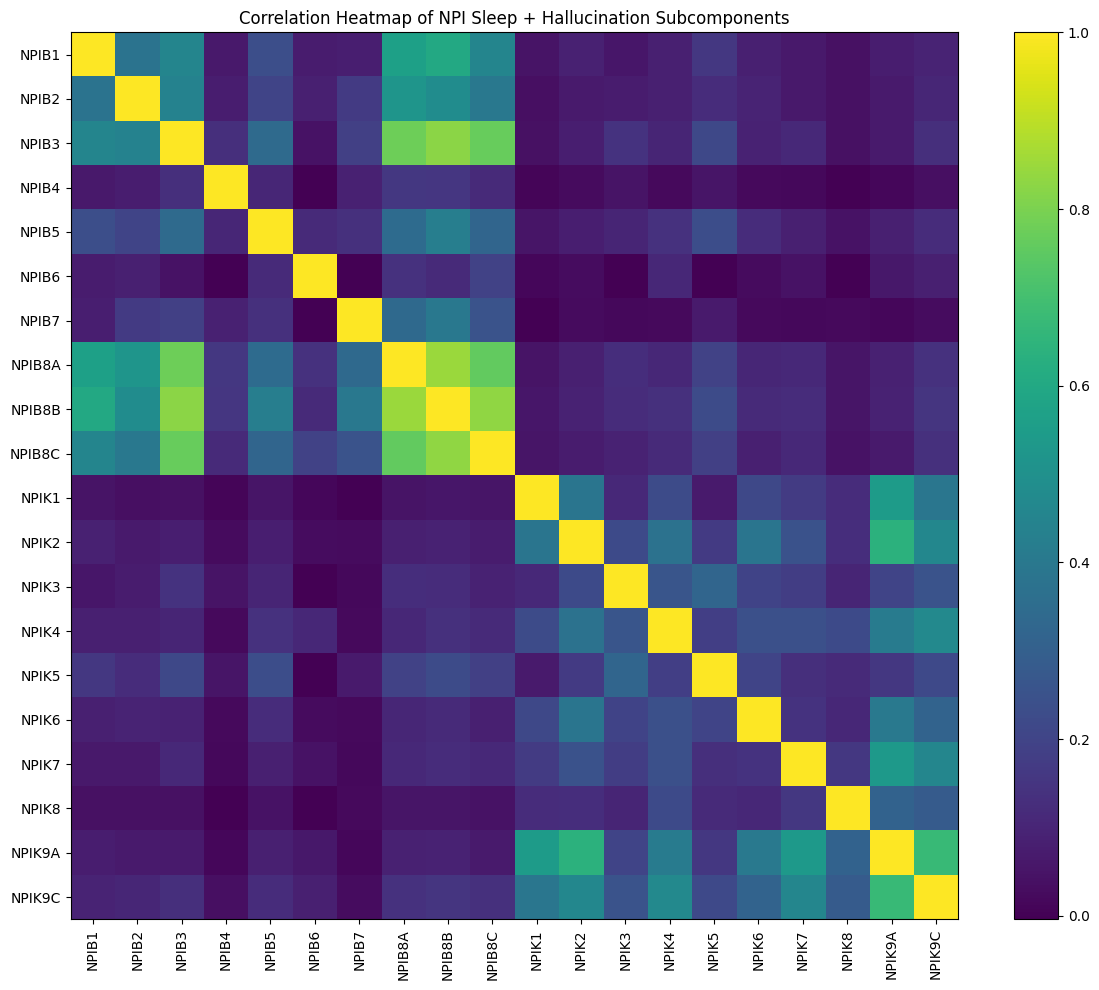

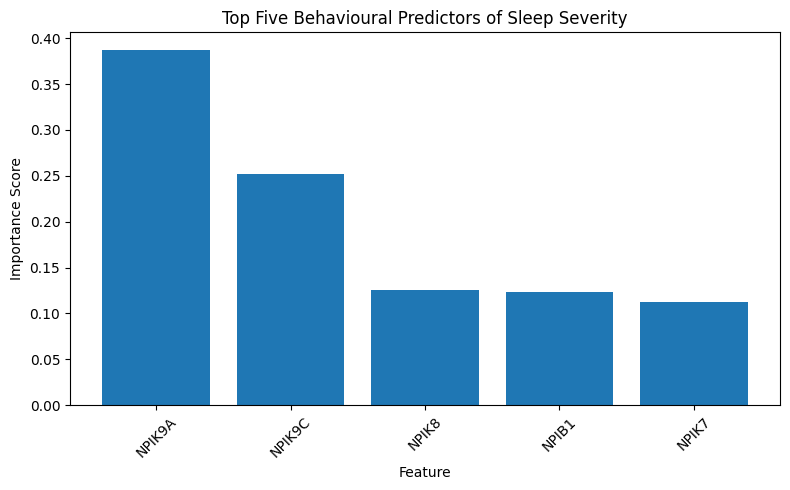

,Feature,Interpretation
0,NPIK1,Difficulty falling asleep
1,NPIK2,Waking during the night
2,NPIK3,Early morning awakening
3,NPIK4,Excessive daytime sleepiness
4,NPIK5,Disturbed sleep–wake cycle
5,NPIK6,Nighttime wandering
6,NPIK7,Restless or repetitive nighttime activity
7,NPIK8,Severity of nocturnal behavioural disturbance
8,NPIK9A,Frequency of nighttime symptoms
9,NPIK9B,Severe-symptom frequency (label-defining varia...


In [ ]:
# ======================================================
# 1. IMPORTS
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# 2. LOAD DATA
# ======================================================
df = pd.read_csv("All_Subjects_NPI_22Jan2025.csv", low_memory=False)

# Identify NPIK + NPIB behavioural subcomponents
beh_cols = [c for c in df.columns if c.startswith("NPIK") or c.startswith("NPIB")]

# Remove domain totals + label generator
drop_cols = ["NPIK", "NPIKTOT", "NPIB", "NPIBTOT", "NPIK9B"]
beh_cols = [c for c in beh_cols if c not in drop_cols]

# Convert to numeric
beh_df = df[beh_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# ======================================================
# 3. CORRELATION HEATMAP (NPI-K/B only)
# ======================================================
plt.figure(figsize=(12,10))
corr = beh_df.corr()

plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.title("Correlation Heatmap of NPI Sleep + Hallucination Subcomponents")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

# ======================================================
# 4. FEATURE IMPORTANCE PLOT
# (using YOUR actual top 5 from model results)
# ======================================================
features = ["NPIK9A", "NPIK9C", "NPIK8", "NPIB1", "NPIK7"]
importance = [0.386997, 0.251496, 0.125437, 0.123523, 0.112547]

imp_df = pd.DataFrame({"Feature": features, "Importance": importance})

plt.figure(figsize=(8,5))
plt.bar(imp_df["Feature"], imp_df["Importance"])
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.title("Top Five Behavioural Predictors of Sleep Severity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ======================================================
# 5. TABLE: Meaning of NPIK1–NPIK9C
# ======================================================
mapping = {
    "NPIK1": "Difficulty falling asleep",
    "NPIK2": "Waking during the night",
    "NPIK3": "Early morning awakening",
    "NPIK4": "Excessive daytime sleepiness",
    "NPIK5": "Disturbed sleep–wake cycle",
    "NPIK6": "Nighttime wandering",
    "NPIK7": "Restless or repetitive nighttime activity",
    "NPIK8": "Severity of nocturnal behavioural disturbance",
    "NPIK9A": "Frequency of nighttime symptoms",
    "NPIK9B": "Severe-symptom frequency (label-defining variable)",
    "NPIK9C": "Caregiver distress associated with nighttime behaviours"
}

map_df = pd.DataFrame(mapping.items(), columns=["Feature", "Interpretation"])
map_df


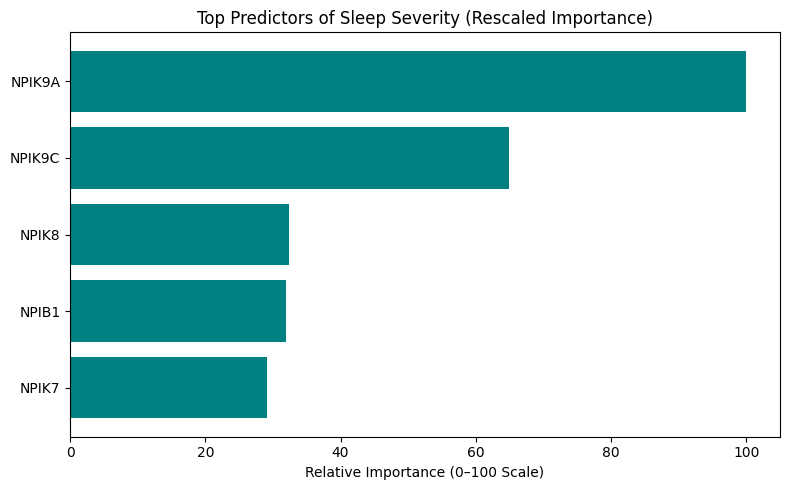

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Your features + importances
features = ["NPIK9A", "NPIK9C", "NPIK8", "NPIB1", "NPIK7"]
importance = np.array([0.386997, 0.251496, 0.125437, 0.123523, 0.112547])

# Rescale to 0–100 for a better figure
scaled = (importance / importance.max()) * 100

plt.figure(figsize=(8,5))
plt.barh(features, scaled, color="teal")
plt.xlabel("Relative Importance (0–100 Scale)")
plt.title("Top Predictors of Sleep Severity (Rescaled Importance)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


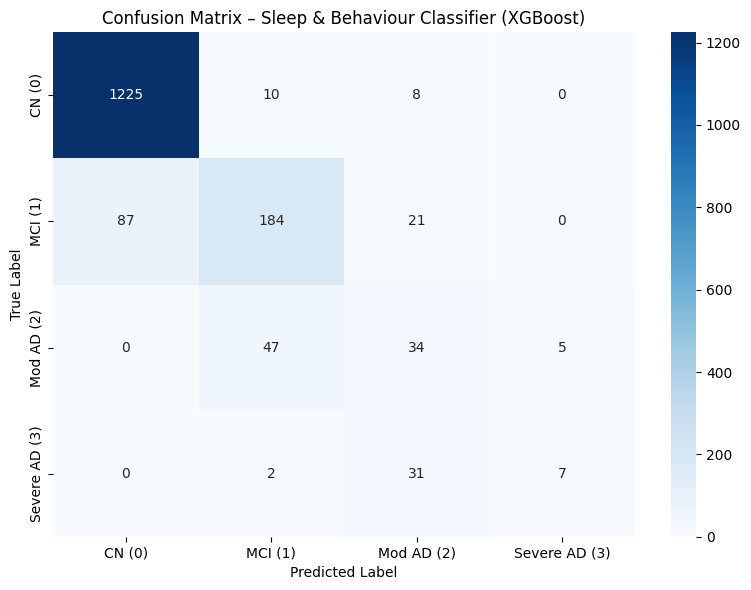

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ----------------------
# CONFUSION MATRIX VALUES
# ----------------------
# Matches EXACTLY the matrix you provided:
# [[1225, 10, 8, 0],
#  [87, 184, 21, 0],
#  [0, 47, 34, 5],
#  [0, 2, 31, 7]]

cm = np.array([
    [1225, 10, 8, 0],
    [87, 184, 21, 0],
    [0, 47, 34, 5],
    [0, 2, 31, 7]
])

# ----------------------
# PLOT SETTINGS
# ----------------------
labels = ['CN (0)', 'MCI (1)', 'Mod AD (2)', 'Severe AD (3)']

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=True
)

plt.title("Confusion Matrix – Sleep & Behaviour Classifier (XGBoost)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
